## Import Libraries

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time

from sklearn.model_selection import train_test_split
from sklearn.model_selection import PredefinedSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV



## Global Variables

In [88]:
seed = 42

FILENAME = "../data/train.csv"

# features = []

## Load the dataset

In [89]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

In [90]:
# Printing informations
rows = df.shape[0]
cols = df.shape[1]
feature_list = df.columns.to_list()

print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")
for i in feature_list:
    print(i)

# Righe: 148301 # Colonne: 145

loan_contract_approved_amount
loan_portfolio_total_funded
investor_side_funded_amount
loan_contract_term_months
loan_contract_interest_rate
loan_payment_installments_count
borrower_profile_employment_length
borrower_housing_ownership_status
borrower_income_annual
borrower_income_verification_status
loan_issue_date
loan_status_current_code
loan_payment_plan_flag
loan_purpose_category
loan_title
borrower_address_zip
borrower_address_state
borrower_dti_ratio
credit_delinquencies_2yrs
credit_history_earliest_line
fico_score_low_bound
fico_score_high_bound
credit_inquiries_6m
months_since_last_delinquency
months_since_last_public_record
credit_open_accounts
credit_public_records
revolving_balance
revolving_utilization
credit_total_accounts
listing_initial_status
outstanding_principal_balance
outstanding_principal_investor_side
total_payment_received
total_payment_investor_side
total_received_principal
total_received_interest
total_received_late_fees
recoverie

In [91]:
#print(df.duplicated().sum())

#df2 = df.T.drop_duplicates().T
#print(df2.shape[1])

# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df2 = df.T.drop_duplicates().T


df.drop_duplicates(inplace=True)
print(df.shape[0])


Ci sono colonne con lo stesso nome? False
148301


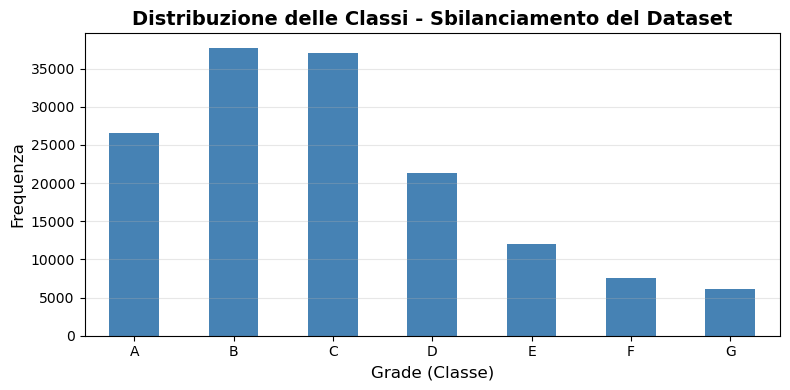


Percentuali per classe:
grade
A    17.892664
B    25.446221
C    25.003877
D    14.333686
E     8.147619
F     5.073465
G     4.102467
Name: proportion, dtype: float64


In [92]:
# Conta delle classi
grade_counts = df["grade"].value_counts().sort_index()

# Crea il bar plot
plt.figure(figsize=(8, 4))
grade_counts.plot(kind='bar', color='steelblue')
plt.title('Distribuzione delle Classi - Sbilanciamento del Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Grade (Classe)', fontsize=12)
plt.ylabel('Frequenza', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostra anche le percentuali
print("\nPercentuali per classe:")
print(df["grade"].value_counts(normalize=True).sort_index() * 100)


In [93]:
# Esplorazione Nan
nan = df.isna().sum() 
nan_percentages = nan / rows * 100

# Creare un DataFrame per visualizzare in forma tabellare
nan_table = pd.DataFrame({
    'Feature': nan_percentages.index,
    'Nan': nan.values,
    'Percentuale NaN (%)': nan_percentages.values
}).reset_index(drop=True).sort_values(by='Percentuale NaN (%)')

print(nan_table.to_string(index=False))

                                          Feature    Nan  Percentuale NaN (%)
                                            grade      0             0.000000
                            credit_public_records    881             0.594062
                        loan_contract_term_months    890             0.600131
                           borrower_address_state    895             0.603502
                         total_received_principal    900             0.606874
                           total_payment_received    903             0.608897
                        credit_delinquencies_2yrs    917             0.618337
                   debt_settlement_flag_indicator    919             0.619686
                                  tax_liens_total    926             0.624406
                              credit_inquiries_6m    927             0.625080
                  loan_payment_installments_count    927             0.625080
                          total_received_interest    932        

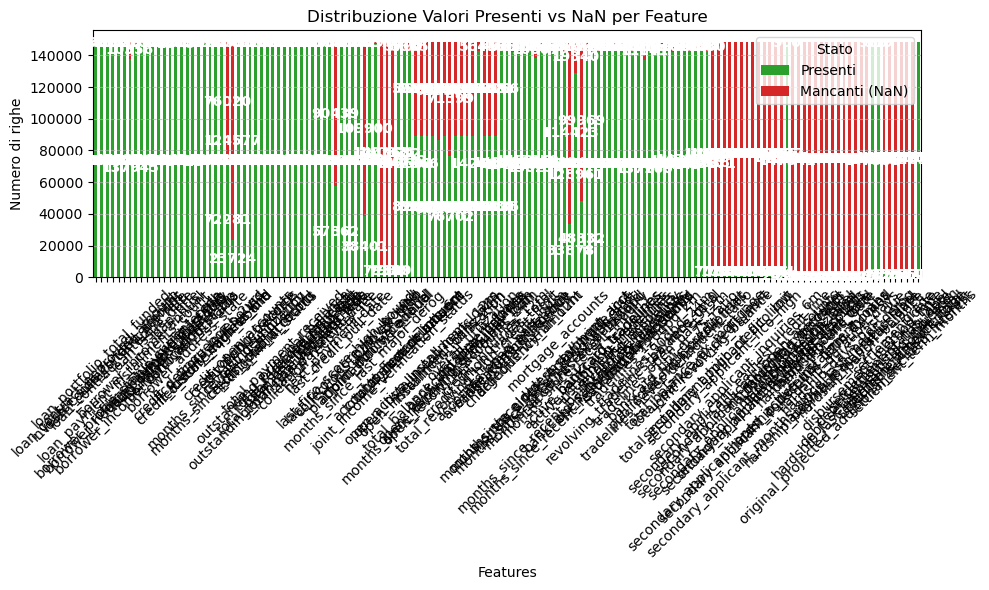

In [94]:
### TODO
df_plot = pd.DataFrame({
    'Presenti': df.notna().sum(),
    'Mancanti (NaN)': df.isna().sum()
})

# 2. Creiamo il grafico a barre sovrapposte
# color: verde per i presenti, rosso per i mancanti (come i segnali stradali)
ax = df_plot.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], figsize=(10, 6))

# 3. Aggiungiamo i numeri dentro le barre
for rect in ax.patches:
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()
    
    # Scriviamo il numero solo se è maggiore di 0
    if height > 0:
        ax.text(x + width/2, y + height/2, int(height), 
                ha='center', va='center', color='white', fontweight='bold')

# 4. Abbelliamo il grafico
plt.title('Distribuzione Valori Presenti vs NaN per Feature')
plt.xlabel('Features')
plt.ylabel('Numero di righe')
plt.xticks(rotation=45) # Inclina i nomi delle colonne per leggerli meglio
plt.legend(loc='upper right', title='Stato')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

1. Splitting
2. Ecoding
3. Scaling
4. PCA
5. 

In [95]:
# Splitting labels

X = df.drop(columns=["grade"])
y = df["grade"]


print(X.shape)
print(y.shape)

(148301, 144)
(148301,)


In [96]:
feature_dtypes_list = df.dtypes
""" for i,j in feature_dtypes_list.items():
    print(i, j)
 """

print(feature_dtypes_list.unique())

# Creare un DataFrame per visualizzare in forma tabellare
feature_dtypes_table = pd.DataFrame({
    'Feature': feature_dtypes_list.index,
    'Type': feature_dtypes_list.values,
    'Example first row': df.iloc[0]
    
}).reset_index(drop=True).sort_values(by='Type')

print(feature_dtypes_table.to_string(index=False))

[dtype('float64') dtype('O')]
                                          Feature    Type       Example first row
                    loan_contract_approved_amount float64                 12000.0
                            satisfactory_accounts float64                     7.0
                revolving_tradelines_balance_gt_0 float64                5.054335
                               revolving_accounts float64                     9.0
                        open_revolving_tradelines float64                     6.0
                           installment_tradelines float64                     2.0
                              bankcard_tradelines float64                6.277382
                   bankcard_satisfactory_accounts float64                5.503904
                      active_revolving_tradelines float64                     5.0
                       active_bankcard_tradelines float64                     5.0
                             accounts_ever_120dpd float64           

In [97]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
for i in categorical_features:
    print(X[i].value_counts().sort_index())
    print("\n")

# extract digits and cast to float
X['loan_contract_term_months'] = X['loan_contract_term_months'].str.extract(r'(\d+)').astype(float)
print(X['loan_contract_term_months'].value_counts().sort_index())

X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].str.replace(r'\+? years?', '', regex=True)
mappings = { '< 1': 0, '10': 10 }
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].replace(mappings).astype(float)
print(X['borrower_profile_employment_length'].value_counts().sort_index())

# drop non significant columns
X.drop('loan_title', axis=1, inplace=True)

# TODO encodare y

loan_contract_term_months
36 months    97786
60 months    49625
Name: count, dtype: int64


borrower_profile_employment_length
1 year        9586
10+ years    48504
2 years      13298
3 years      11703
4 years       8980
5 years       9147
6 years       6693
7 years       6176
8 years       6103
9 years       5335
< 1 year     12420
Name: count, dtype: int64


borrower_housing_ownership_status
any            66
mortgage    71697
none            3
other          16
own         16621
rent        58939
Name: count, dtype: int64


borrower_income_verification_status
not verified       45206
source verified    57451
verified           44664
Name: count, dtype: int64


loan_issue_date
apr-2008      24
apr-2009      17
apr-2010      50
apr-2011      99
apr-2012     192
            ... 
sep-2014     779
sep-2015    1903
sep-2016    1864
sep-2017    2779
sep-2018    2461
Name: count, Length: 138, dtype: int64


loan_status_current_code
charged off                                            207

In [98]:
# Split train test: 0.25
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)

In [99]:
## TODO: quale encoder e' meglio usare?
# ricerca: categorical feature transform in ml
# https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/

for col in X_train[categorical_features].columns:    
    le = LabelEncoder()
    values_train = X_train[col].dropna().values 
    values_val = X_val[col].dropna().values
    
    values = np.union1d(values_train, values_val)
    
    le = le.fit(values)
    X_train[col] = le.transform(X_train[col])
    X_val[col] = le.transform(X_val[col])

print(X_train.head())

# TODO:  

KeyError: "['loan_title'] not in index"

In [ ]:
df1 = df1.dropna()
X = df1[features].to_numpy()
y = df1["position"].to_numpy()

le = LabelEncoder()
le.fit(y)
y = le.transform(y)

## Define the scalers to be used

In [ ]:
# Scalers to test
scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler()
}

## Apply Logistic Regression

In [ ]:
# train/val split 
indices = np.arange(X.shape[0])
train_idx, val_idx = train_test_split(indices, test_size=0.1, stratify=y, random_state=seed)

X_val_raw = X[val_idx,:]
y_val = y[val_idx]
X_train_raw = X[train_idx,:]
y_train = y[train_idx]


best_score = 0
for name, scaler in scalers.items():
    # scale data
    

    # train model
    
    print("Performance:",score)

    if score > best_score:
        best_score = score
        file_scaler = open("lr_scaler.save","wb")
        pickle.dump(scaler, file_scaler)
        file_clf = open("lr.save","wb")
        pickle.dump(clf, file_clf)
        file_clf.close()



## Apply Support Vector Classifier with hyperparameters tuning

In [ ]:
# SVC param grid
param_grid_svc = {'clf__C': [0.1, 1, 10, 100, 1000],
              'clf__kernel': ["linear", "poly", "rbf"]}

# Grid Search with Pipeline
best_score = 0
for scaler_name, scaler in scalers.items():

        pipeline = Pipeline([
            ("scaler", scaler),
            ("clf", SVC(random_state=seed))
        ])

        # Perform Grid Search
        

        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            file = open("svc_scaler.save","wb")
            pickle.dump(grid.best_estimator_['scaler'], file)
            file.close()
            file = open("svc.save","wb")
            pickle.dump(grid.best_estimator_['clf'], file)
            file.close()


## Apply Random Forests with hyperparameters tuning

In [ ]:
param_grid_rf = {
    
}

# Grid Search with Pipeline
best_score = 0

for scaler_name, scaler in scalers.items():

        pipeline = Pipeline([
            ("scaler", scaler),
            ("clf", RandomForestClassifier(random_state=seed))
        ])

        # Perform Grid Search

        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            file = open("rf_scaler.save","wb")
            pickle.dump(grid.best_estimator_['scaler'], file)
            file.close()
            file = open("rf.save","wb")
            pickle.dump(grid.best_estimator_['clf'], file)
            file.close()